In [1]:
!nvidia-smi

Tue Apr 14 18:29:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [3]:

from roboflow import Roboflow
rf = Roboflow(api_key="Fz2zjcqjsrM0yKA7gWEW")
project = rf.workspace("hendaru").project("classification-design")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Classification-Design-1 in folder:: 100%|██████████| 296/296 [00:00<00:00, 8214.28it/s]


In [5]:
# Ultralytics
from ultralytics import YOLO
model = YOLO("yolov9c.pt")
model.info()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv9c summary: 358 layers, 25,590,912 parameters, 0 gradients, 104.0 GFLOPs


(358, 25590912, 0, 104.02268160000003)

In [8]:
from ultralytics import YOLO

# Load a YOLOv8 classification model
model = YOLO("yolov8n-cls.pt") # Using a classification-specific model

# Train the model, pointing 'data' directly to the dataset location for classification
results = model.train(data=dataset.location, epochs=20, imgsz=640)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Classification-Design-1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [9]:
predict_results = model.predict('sample.png')

# The predict_results object can be a list of results, so iterate through them
for res in predict_results:
    names = res.names # Get class names
    probs = res.probs.data.tolist() # Get probabilities

    print(f"Predicted class: {names[probs.index(max(probs))]}")
    print(f"Probabilities: {probs}")

    # If you want to see the full result object
    # display(res)


image 1/1 /content/sample.png: 640x640 Modern Design 0.57, Minimalist Design 0.38, Flat Design 0.02, Vintage Design 0.02, Retro Design 0.01, 4.3ms
Speed: 65.1ms preprocess, 4.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)
Predicted class: Modern Design
Probabilities: [0.02346605807542801, 0.3774983286857605, 0.5697134733200073, 0.010333871468901634, 0.01898825354874134]


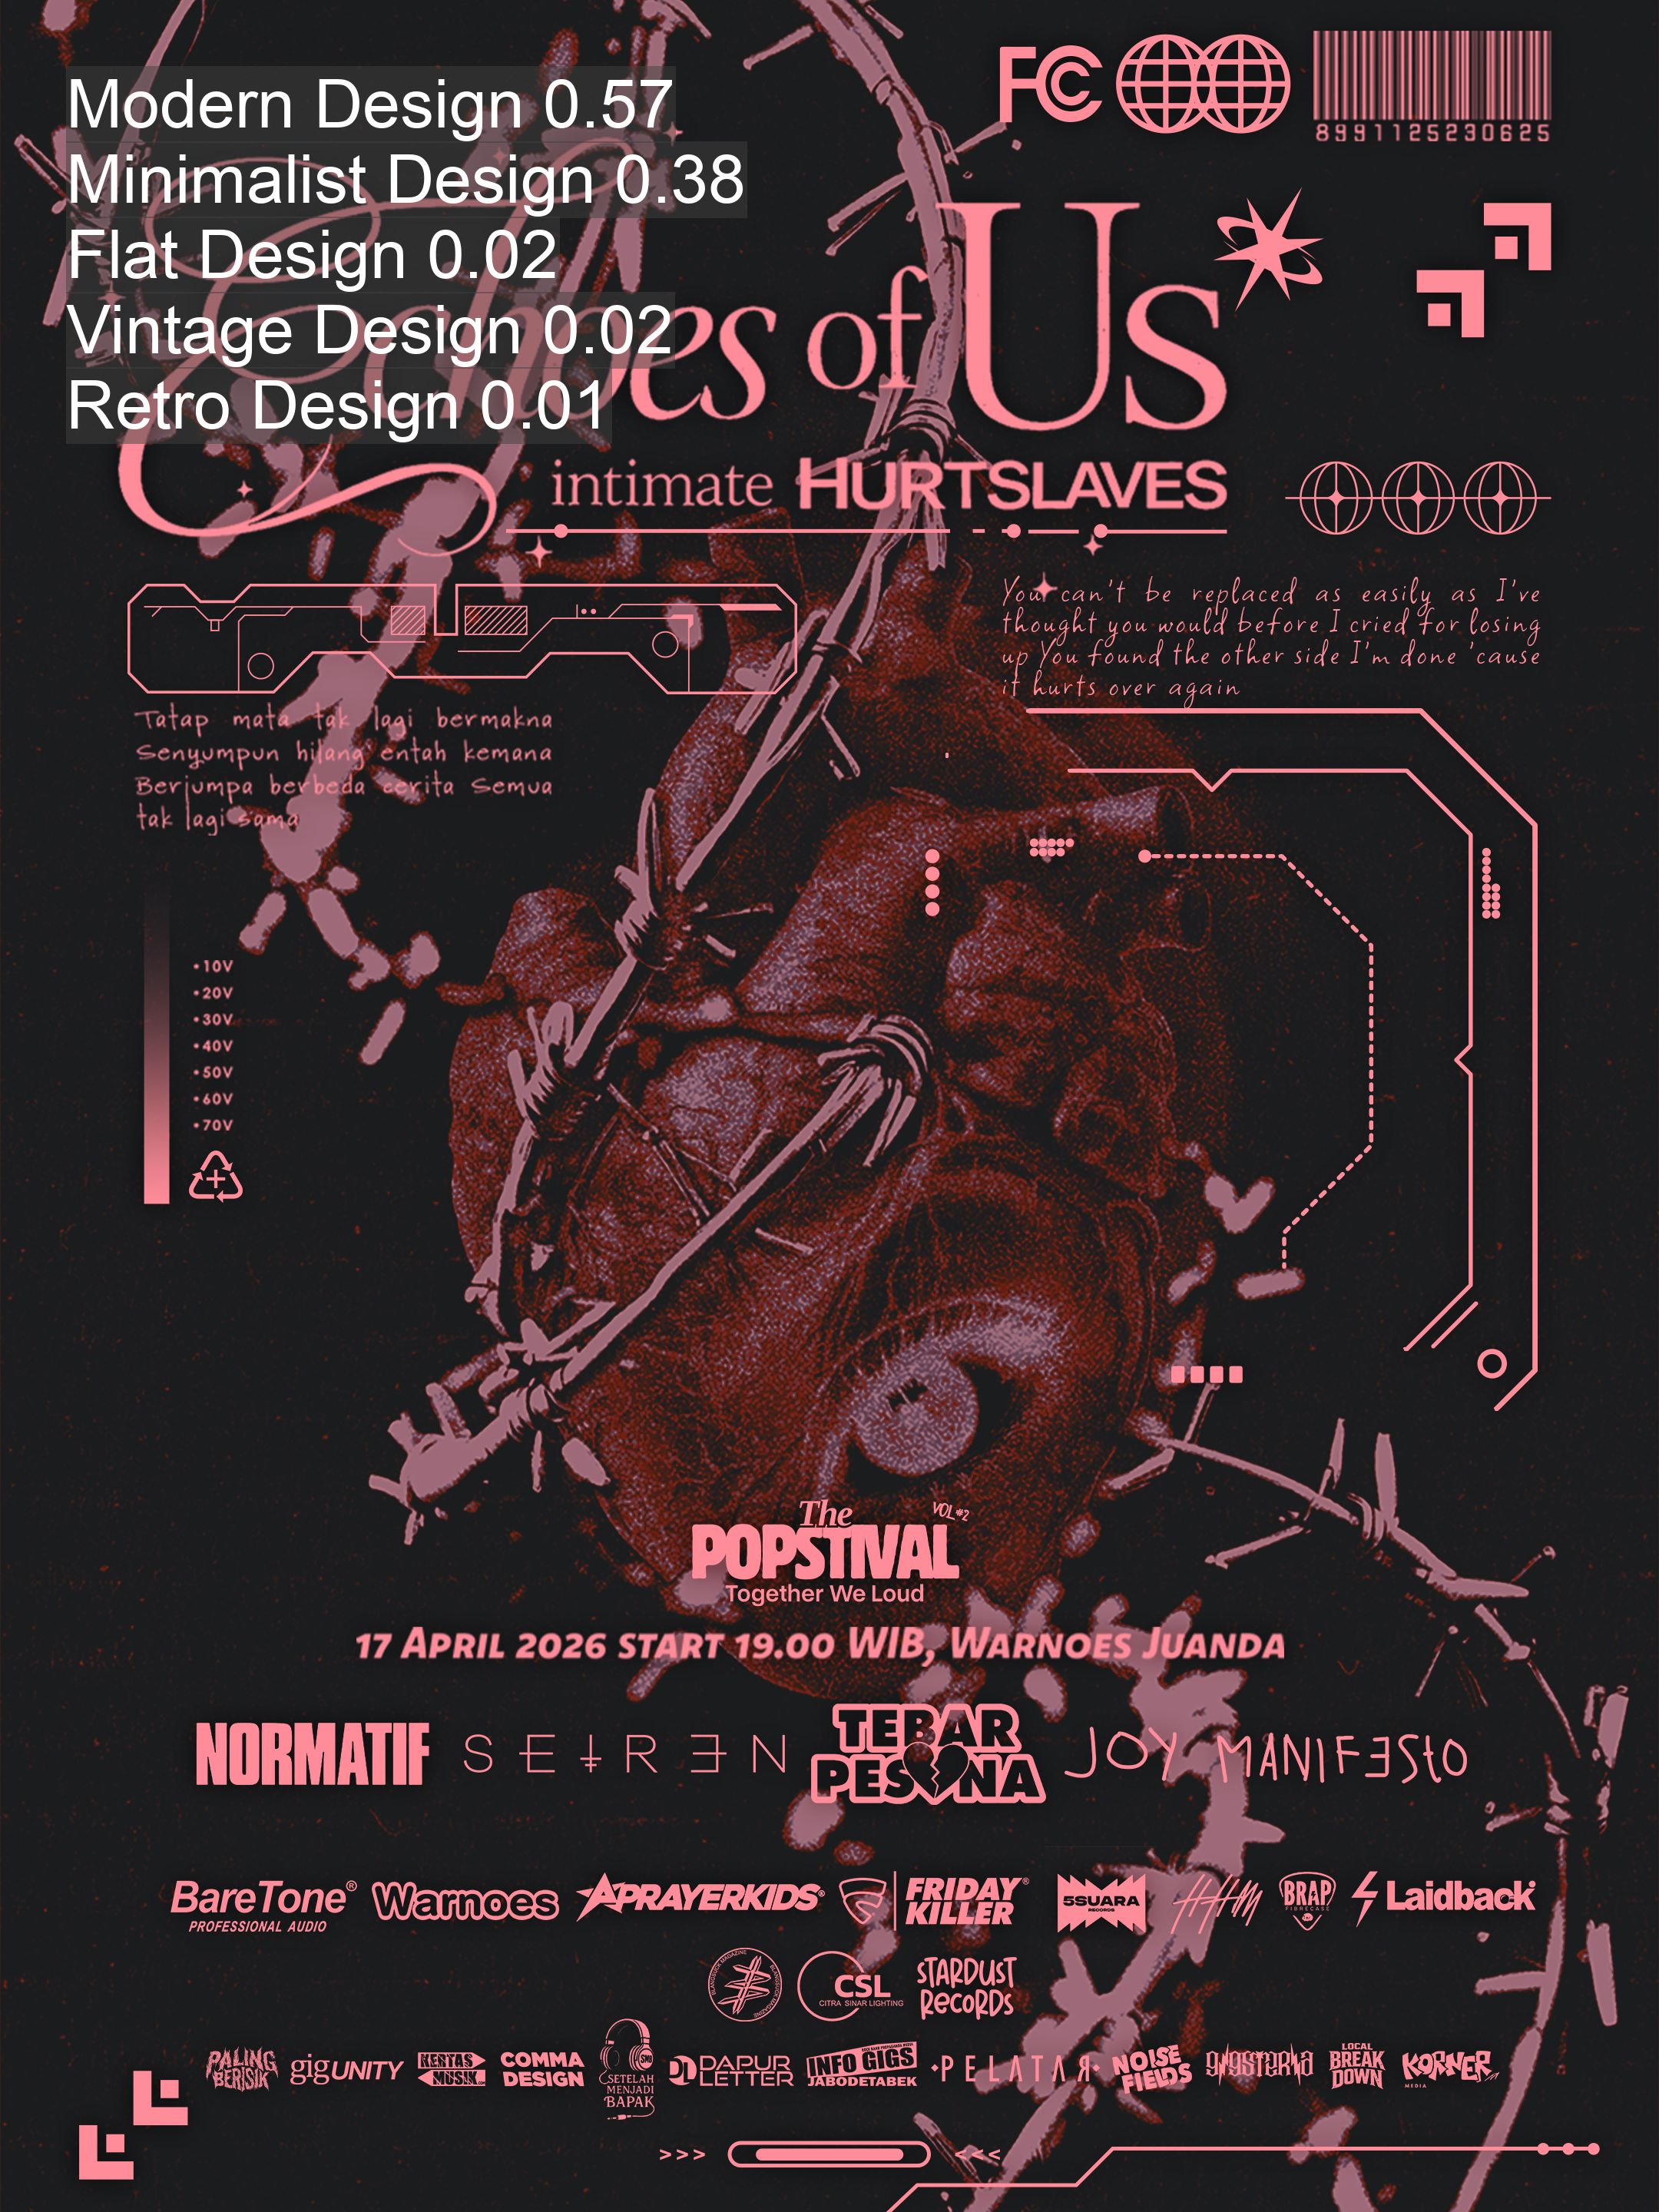

In [11]:
from PIL import Image

for res in predict_results:
    im_array = res.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    display(im)


In [12]:
!pip install openai

To use the OpenAI API, you'll need an API key. Please add your OpenAI API key to Colab secrets under the name `OPENAI_API_KEY`. Then, we'll initialize the client.

In [13]:
import openai
import base64
from io import BytesIO
from google.colab import userdata

OPENAI_API_KEY="REDACTED_OPENAI_KEY"
client = openai.OpenAI(api_key=OPENAI_API_KEY)

Now, let's encode the `sample.png` image into base64 format, which is required for sending it to the OpenAI API.

In [14]:
import cv2

# Assuming predict_results is available from previous execution and contains the image data
# We'll take the first image from predict_results for analysis
if predict_results and hasattr(predict_results[0], 'plot'):
    # Get the plotted image as a NumPy array (BGR format)
    im_array = predict_results[0].plot()
    # Convert BGR to RGB for PIL
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

    # Convert NumPy array to PIL Image
    pil_img = Image.fromarray(im_rgb)

    # Save the PIL image to a bytes buffer
    buffer = BytesIO()
    pil_img.save(buffer, format="PNG")
    encoded_image = base64.b64encode(buffer.getvalue()).decode('utf-8')
    print("Image encoded successfully.")
else:
    print("Error: 'predict_results' or image data not found. Please ensure prediction was successful.")
    encoded_image = None

Image encoded successfully.


Now I will send the image to the OpenAI `gpt-4o` model with your request for a summary, improvements, a score, and recommendations.

In [17]:
if encoded_image:
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Analyze the design style in this image. Provide a detailed summary of the detected class ('Modern Design' as per previous detection), suggest improvements for the design shown, give a score out of 10 for its adherence to 'Modern Design' principles, and offer specific recommendations for design details to enhance it further. Response in raw text, not markdown format using bahasa."},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{encoded_image}"
                        },
                    },
                ],
            }
        ],
        max_tokens=500
    )
    print(response.choices[0].message.content)
else:
    print("Cannot send request to OpenAI API as the image was not encoded.")

Gaya desain dalam gambar ini cenderung mengarah ke 'Modern Design' dengan skor deteksi 0,57. Desain ini menampilkan elemen-elemen yang cenderung futuristik dan abstrak. Warna yang digunakan kontras dan cenderung gelap dengan sentuhan warna terang, menciptakan suasana yang dramatis. Tipografi modern dan elemen geometris, seperti garis dan bentuk, digunakan untuk membingkai teks dan visual.

Untuk meningkatkan desain agar lebih sesuai dengan prinsip 'Modern Design', berikut beberapa saran:

1. **Penyederhanaan Elemen**: Kurangi jumlah elemen grafis yang tidak diperlukan untuk menciptakan ruang kosong yang lebih bersih dan lebih rapi.

2. **Konsistensi Tipografi**: Gunakan lebih sedikit variasi font dan ukuran teks untuk menciptakan tampilan yang lebih konsisten dan harmonis.

3. **Penggunaan Warna**: Pertimbangkan palet warna yang lebih minimalis dengan konsistensi nuansa warna, mengutamakan beberapa warna dominan untuk fokus visual yang lebih terarah.

4. **Keseimbangan Visual**: Atur e